In [ ]:
# 필요 라이브러리 설치
%pip install -q onnxruntime numpy pillow matplotlib seaborn scikit-learn

In [1]:
import os
import io
import glob
import numpy as np
from PIL import Image
import onnxruntime as ort
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 리눅스 환경 한글 폰트 설정 (나눔고딕)
plt.rc("font", family="NanumGothic")
plt.rcParams["axes.unicode_minus"] = False

In [2]:
# 1. ONNX 모델 세션 로드 및 입력 규격 확인
sess = ort.InferenceSession("best.onnx")
input_name = sess.get_inputs()[0].name
SIZE = tuple(sess.get_inputs()[0].shape[2:])  # (224, 224)
print(f"입력 텐서명: {input_name}, 입력 크기: {SIZE}")

# 2. 클래스 목록(classes.txt) 로드
with open("classes.txt", "r", encoding="utf-8") as f:
    classes = [line.strip() for line in f if line.strip()]
print("분류 클래스 목록:", classes)

입력 텐서명: tensor, 입력 크기: (224, 224)
분류 클래스 목록: ['가을 웜톤', '겨울 쿨톤', '봄 웜톤', '여름 쿨톤']


In [3]:
# 단일 이미지(test.jpg) 추론 테스트
with open("test.jpg", "rb") as f:
    img_bytes = f.read()

img = Image.open(io.BytesIO(img_bytes)).convert("RGB").resize(SIZE)
x = np.array(img, dtype=np.float32) / 255.0
x = np.transpose(x, (2, 0, 1))
x = np.expand_dims(x, axis=0)

outputs = sess.run(None, {input_name: x})
pred_class = classes[outputs[0].argmax()]
print(f"test.jpg 예측 결과: {pred_class}")

test.jpg 예측 결과: 여름 쿨톤


In [4]:
# dataset/val 내의 전체 이미지 추론 진행
val_dir = "dataset/val"
y_true = []
y_pred = []

for class_idx, class_name in enumerate(classes):
    class_folder = os.path.join(val_dir, class_name)
    img_paths = glob.glob(os.path.join(class_folder, "*.*"))
    print(f"[{class_name}] 총 {len(img_paths)}개 이미지 추론 중...")
    
    for p in img_paths:
        try:
            img = Image.open(p).convert("RGB").resize(SIZE)
            x = np.array(img, dtype=np.float32) / 255.0
            x = np.transpose(x, (2, 0, 1))
            x = np.expand_dims(x, axis=0)
            
            outputs = sess.run(None, {input_name: x})
            pred_idx = int(outputs[0].argmax())
            
            y_true.append(class_idx)
            y_pred.append(pred_idx)
        except Exception as e:
            print(f"에러 ({p}): {e}")

print(f"총 {len(y_true)}개 검증 데이터셋 추론 완료!")


[가을 웜톤] 총 107개 이미지 추론 중...
[겨울 쿨톤] 총 106개 이미지 추론 중...
[봄 웜톤] 총 90개 이미지 추론 중...
[여름 쿨톤] 총 87개 이미지 추론 중...
총 390개 검증 데이터셋 추론 완료!


Text(51.722222222222214, 0.5, 'Actual')

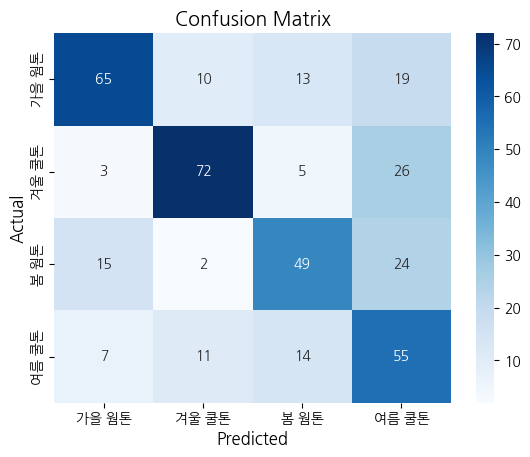

In [10]:
# 혼돈 행렬(Confusion Matrix) 계산 및 시각화
cm = confusion_matrix(y_true, y_pred)
# 1. 빈도수(Count) 기준 혼돈 행렬
ax=sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",xticklabels=classes, yticklabels=classes)
ax.set_title("Confusion Matrix", fontsize=14)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Actual", fontsize=12)

Text(51.722222222222214, 0.5, 'Actual')

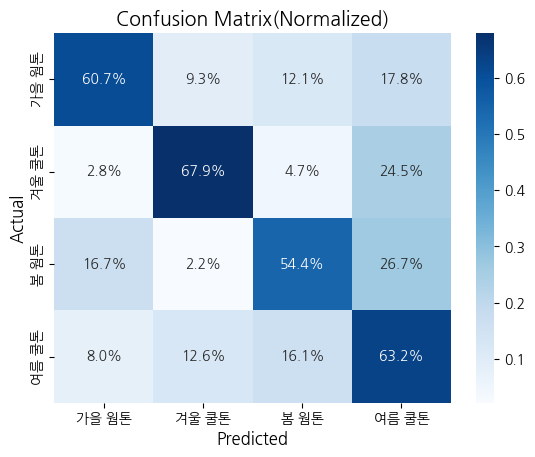

In [14]:
cm_norm = confusion_matrix(y_true, y_pred, normalize="true")

# 2. 정규화 비율(Normalized %) 기준 혼돈 행렬
ax=sns.heatmap(cm_norm, annot=True, fmt=".1%", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
ax.set_title("Confusion Matrix(Normalized)", fontsize=14)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Actual", fontsize=12)